# LUNG-CANC'AIR — Analyse spatiale de Moran

> **Objectif :** Tester l'association spatiale entre la présence de mutations NF
> (non-fumeurs) et la proximité des industries Seveso Seuil Haut (SH) en IDF.
>
> **Analyses réalisées :**
> ```
> 0  → Configuration
> 1  → Chargement données + calcul expositions ICPE
> 2  → Matrice de poids spatiaux (rayon 3km)
> 3  → Moran's I global univarié (clustering mutations NF)
> 4  → LISA local (carte des clusters)
> 5  → Moran's I bivarié (mutations NF × Seveso SH)
> 6  → LISA bivarié (co-clusters locaux)
> 7  → Synthèse comparative
> ```
>
> **Script utilisé :** `moran_spatial_analysis.py`


---
## PARTIE 0 — Configuration

> Modifier ici les chemins et paramètres. Ne rien changer en dessous.

In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\ProgramData\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
import site
print(site.getsitepackages())

['c:\\ProgramData\\anaconda3', 'c:\\ProgramData\\anaconda3\\Lib\\site-packages']


In [3]:
import os

dossier = r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\pneumodetect\src"
print("Dossier existe :", os.path.exists(dossier))
print("Fichiers dans le dossier :")
for f in os.listdir(dossier):
    print(f"  {f}")

Dossier existe : True
Fichiers dans le dossier :
  addok_conf.py
  batch_fix.py
  filter_ndjson.py
  lungcancair_analyses.py
  lungcancair_engine.py
  lungcancair_engine_.py
  moran_spatial_analysis.py
  visualisations_cohorte.py
  visualisations_stats.py
  __pycache__


In [4]:
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ajouter le dossier du script au path
sys.path.append(r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\pneumodetect\src")

import moran_spatial_analysis as moran
importlib.reload(moran)

# =============================================================================
# ★ CONFIGURATION — Modifier ici uniquement ★
# =============================================================================

CONFIG = {

    # ── Chemins ───────────────────────────────────────────────────────────────
    'patients_csv' : r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Data\patients_geocoded_clean_idf_2018_2023.csv",
    'icpe_shp'     : r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Data\industries_a_risques\icpe.geojson\icpe_idf.shp",
    'output_dir'   : r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Notebooks\output\resultats_moran",

    # ── Paramètres spatiaux ───────────────────────────────────────────────────
    'rayon_m'        : 3000,    # ← rayon de voisinage en mètres
    'n_permutations' : 999,     # ← nb permutations pour les tests
    'alpha'          : 0.05,    # ← seuil de significativité

    # ── Colonnes patients ─────────────────────────────────────────────────────
    'col_x'    : 'x',                # longitude WGS84
    'col_y'    : 'y',                # latitude WGS84
    'col_id'   : 'pseudo_provisoire',
    'col_tabac': 'paquet_annee',

    # ── Mutations NF à considérer ─────────────────────────────────────────────
    'mutations_nf' : ['EGFR', 'ALK', 'ROS1', 'RET', 'NTRK', 'ERBB2', 'MET'],
}

print("✅ Configuration définie")
print(f"   Rayon voisinage  : {CONFIG['rayon_m']} m")
print(f"   Permutations     : {CONFIG['n_permutations']}")
print(f"   Mutations NF     : {CONFIG['mutations_nf']}")
print(f"   Figures sauvées  : {CONFIG['output_dir']}")


✅ Configuration définie
   Rayon voisinage  : 3000 m
   Permutations     : 999
   Mutations NF     : ['EGFR', 'ALK', 'ROS1', 'RET', 'NTRK', 'ERBB2', 'MET']
   Figures sauvées  : H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Notebooks\output\resultats_moran


---
## PARTIE 1 — Chargement des données

> Charge les patients géocodés, crée les groupes (mutations NF, non-fumeurs),
> projette en Lambert 93 et calcule les variables d'exposition ICPE.


In [5]:
# ── Chargement patients ──────────────────────────────────────────────────────
df, gdf = moran.charger_patients(CONFIG)

# ── Chargement ICPE ──────────────────────────────────────────────────────────
icpe, icpe_sh, icpe_sb, icpe_ns = moran.charger_icpe(CONFIG)

# ── Calcul expositions ICPE par patient ──────────────────────────────────────
df = moran.calculer_expositions_icpe(df, icpe_sh, icpe_sb, CONFIG['rayon_m'])

print(f"\n✅ Données prêtes")
print(f"   Patients           : {len(df)}")
print(f"   Groupe A (mut. NF) : {df['groupe_A'].sum()} ({df['groupe_A'].mean()*100:.1f}%)")
print(f"   Groupe C (non-fum) : {df['groupe_C'].sum()} ({df['groupe_C'].mean()*100:.1f}%)")
print(f"   Groupe A+C         : {df['groupe_AC'].sum()} ({df['groupe_AC'].mean()*100:.1f}%)")
print(f"   Seveso SH          : {len(icpe_sh)} sites")
print(f"   dist SH médiane    : {df['dist_SH_m'].median():.0f} m")
print(f"   nb SH 3km médiane  : {df['nb_SH_3km'].median():.0f}")


─────────────────────────────────────────────────────────────────
ÉTAPE 1 — Chargement des données patients
─────────────────────────────────────────────────────────────────
  Patients chargés : 1682
  Groupe A (mutations NF)  : 332 (19.7%)
  Groupe C (non-fumeurs)   : 241 (14.3%)
  Groupe A+C               : 434 (25.8%)
  Coordonnées projetées en Lambert 93 ✅

  Chargement ICPE...
  ICPE total : 2919 | SH : 37 | SB : 70 | NS : 2812

  Calcul expositions ICPE (rayon 3000m)...
  dist_SH_m    : médiane=7727m | min=612m | max=24512m
  nb_SH_3km    : médiane=0 | max=2
  score_expo_SH: médiane=0.056

✅ Données prêtes
   Patients           : 1682
   Groupe A (mut. NF) : 332 (19.7%)
   Groupe C (non-fum) : 241 (14.3%)
   Groupe A+C         : 434 (25.8%)
   Seveso SH          : 37 sites
   dist SH médiane    : 7727 m
   nb SH 3km médiane  : 0


#### 📊 Résultats — Chargement données

*À compléter après exécution.*

### 1b — Statistiques descriptives spatiales

── Exposition Seveso SH : Groupe A (mutations NF) vs Groupe B ──
  dist_SH_m  : médiane A=7529m | B=7501m | p=0.818 —
  nb_SH_3km  : médiane A=0.13 | B=0.08 | p=0.113 —

── Exposition Seveso SH : Groupe C (non-fumeurs) vs Groupe D ──
  dist_SH_m  : médiane C=7424m | D=7520m | p=0.402 —


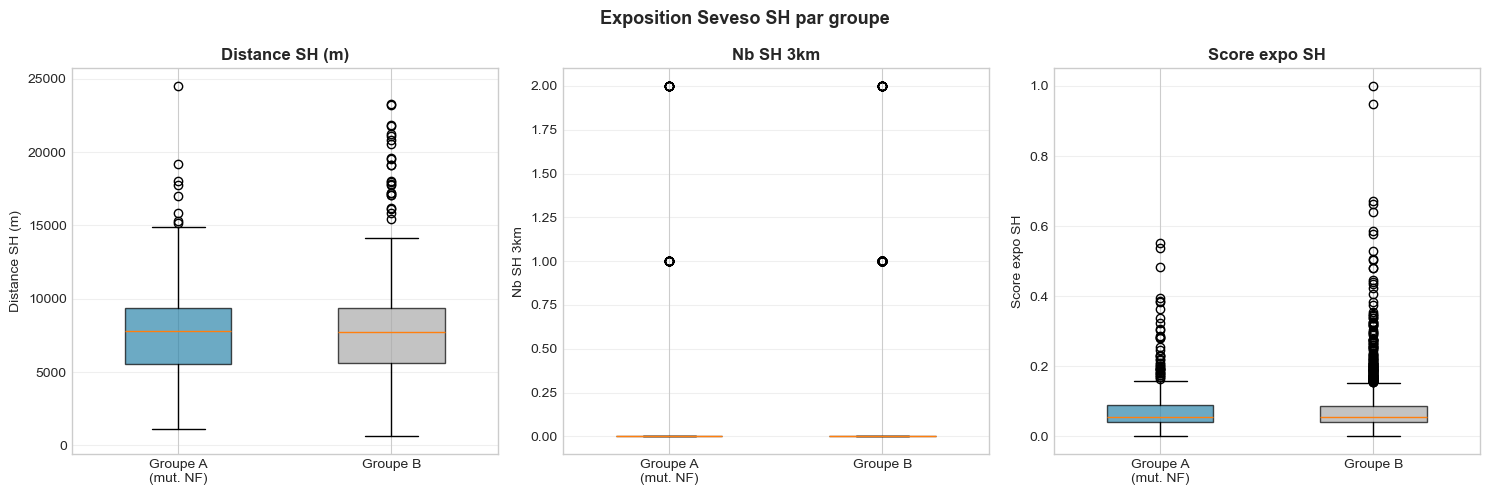

In [6]:
# Comparaison exposition SH : Groupe A vs Groupe B
from scipy.stats import mannwhitneyu

g_A = df[df['groupe_A']==1]['dist_SH_m'].values
g_B = df[df['groupe_A']==0]['dist_SH_m'].values
_, p_dist = mannwhitneyu(g_A, g_B, alternative='two-sided')

g_A_nb = df[df['groupe_A']==1]['nb_SH_3km'].values
g_B_nb = df[df['groupe_A']==0]['nb_SH_3km'].values
_, p_nb = mannwhitneyu(g_A_nb, g_B_nb, alternative='two-sided')

print("── Exposition Seveso SH : Groupe A (mutations NF) vs Groupe B ──")
print(f"  dist_SH_m  : médiane A={g_A.mean():.0f}m | B={g_B.mean():.0f}m | "
      f"p={'<0.001' if p_dist<0.001 else f'{p_dist:.3f}'} "
      f"{'✅' if p_dist<0.05 else '—'}")
print(f"  nb_SH_3km  : médiane A={g_A_nb.mean():.2f} | B={g_B_nb.mean():.2f} | "
      f"p={'<0.001' if p_nb<0.001 else f'{p_nb:.3f}'} "
      f"{'✅' if p_nb<0.05 else '—'}")

# Comparaison Groupe C vs D
g_C = df[df['groupe_C']==1]['dist_SH_m'].values
g_D = df[df['groupe_C']==0]['dist_SH_m'].values
_, p_dist_cd = mannwhitneyu(g_C, g_D, alternative='two-sided')

print(f"\n── Exposition Seveso SH : Groupe C (non-fumeurs) vs Groupe D ──")
print(f"  dist_SH_m  : médiane C={g_C.mean():.0f}m | D={g_D.mean():.0f}m | "
      f"p={'<0.001' if p_dist_cd<0.001 else f'{p_dist_cd:.3f}'} "
      f"{'✅' if p_dist_cd<0.05 else '—'}")

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Exposition Seveso SH par groupe", fontsize=13, fontweight='bold')

for ax, (var, lbl) in zip(axes,
    [('dist_SH_m','Distance SH (m)'),('nb_SH_3km','Nb SH 3km'),
     ('score_expo_SH','Score expo SH')]):
    data_plot = [df[df['groupe_A']==1][var].values,
                 df[df['groupe_A']==0][var].values]
    bp = ax.boxplot(data_plot, labels=['Groupe A\n(mut. NF)','Groupe B'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#2E86AB'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#AAAAAA'); bp['boxes'][1].set_alpha(0.7)
    ax.set_ylabel(lbl); ax.set_title(lbl, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


#### 📊 Résultats — Statistiques descriptives spatiales

*À compléter après exécution.*

---
## PARTIE 2 — Matrice de poids spatiaux

> Construit la matrice W par rayon fixe (`rayon_m` dans CONFIG).
> Vérifie la connectivité — si trop de patients isolés, augmenter le rayon.



─────────────────────────────────────────────────────────────────
ÉTAPE 2 — Matrice de poids spatiaux (rayon 3000m)
─────────────────────────────────────────────────────────────────
  N patients            : 1682
  Rayon                 : 3000 m
  Voisins par patient   : médiane=73 | min=0 | max=284
  Patients isolés (0 voisin) : 71 (4.2%)


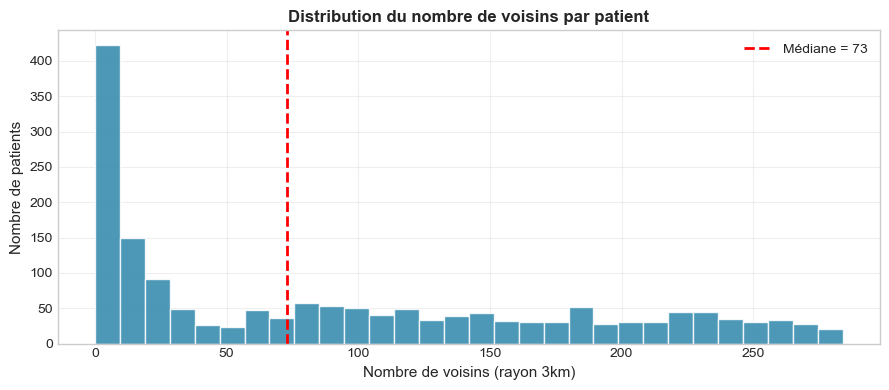


✅ Matrice W construite
   Connectivité : 1611/1682 patients connectés
   Patients isolés : 71


In [7]:
W, n_voisins = moran.construire_matrice_poids(
    df,
    rayon_m = CONFIG['rayon_m'],
    n_permutations = CONFIG['n_permutations']
)

print(f"\n✅ Matrice W construite")
print(f"   Connectivité : {sum(1 for n in n_voisins if n>0)}/{len(df)} patients connectés")
print(f"   Patients isolés : {sum(1 for n in n_voisins if n==0)}")


#### 📊 Résultats — Matrice de poids spatiaux

*À compléter après exécution.*

---
## PARTIE 3 — Moran's I global univarié

> Teste si chaque variable est spatialement autocorrélée.
>
> **I > 0 et p < 0.05** → les valeurs similaires sont regroupées géographiquement
> (clustering spatial).
>
> **I ≈ 0** → distribution aléatoire dans l'espace.


### 3a — Mutations NF (Groupe A)

  ⚠️  71 patients isolés exclus du calcul

  Mutations NF (Groupe A)
  Moran's I = -0.0081 | E[I] = -0.0006
  z-score   = -0.6974
  p-value   = 0.4856 — non sig.
  p-valeur (permutation) = 0.2240 — non sig.


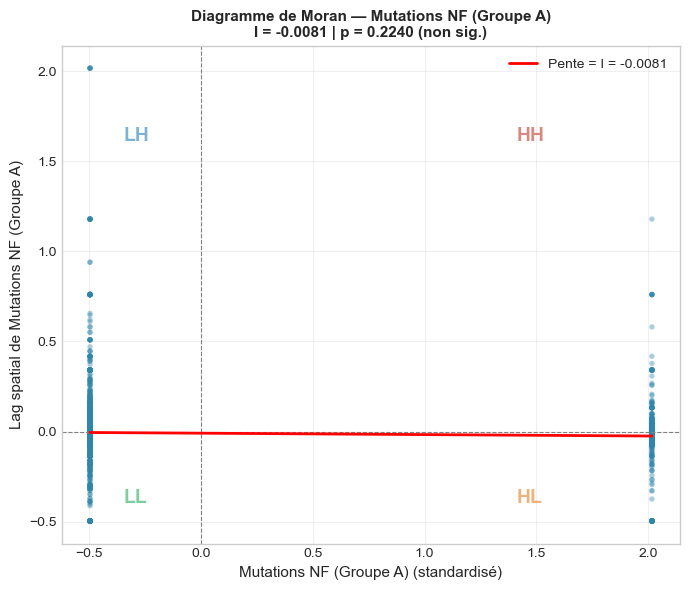

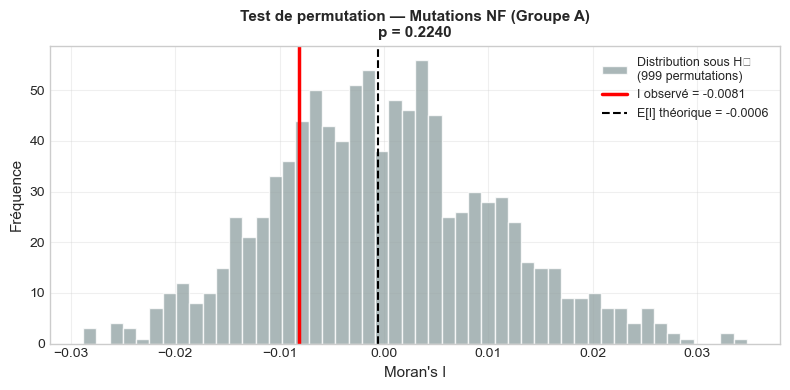

In [8]:
res_moran_A = moran.moran_global_univarie(
    df, W,
    variable = 'groupe_A',
    label    = 'Mutations NF (Groupe A)',
    couleur  = '#2E86AB',
    n_perm   = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran I — Mutations NF

*À compléter après exécution.*

### 3b — Non-fumeurs (Groupe C)

  ⚠️  71 patients isolés exclus du calcul

  Non-fumeurs (Groupe C)
  Moran's I = 0.0010 | E[I] = -0.0006
  z-score   = 0.1520
  p-value   = 0.8792 — non sig.
  p-valeur (permutation) = 0.3700 — non sig.


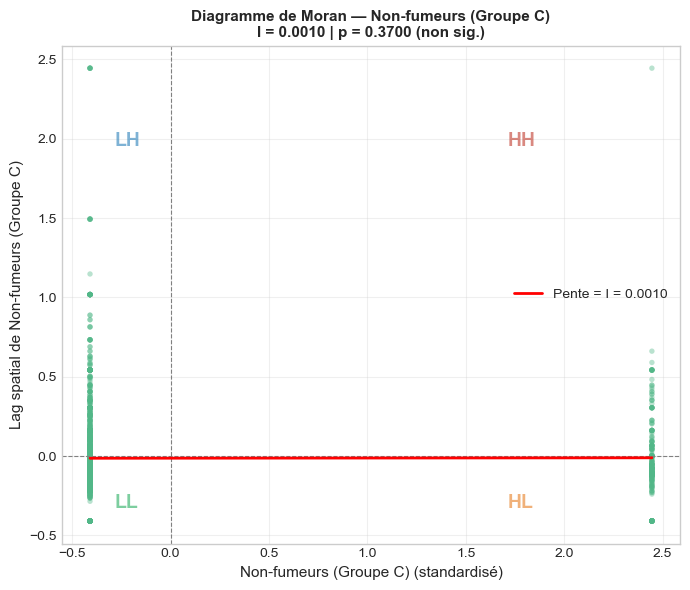

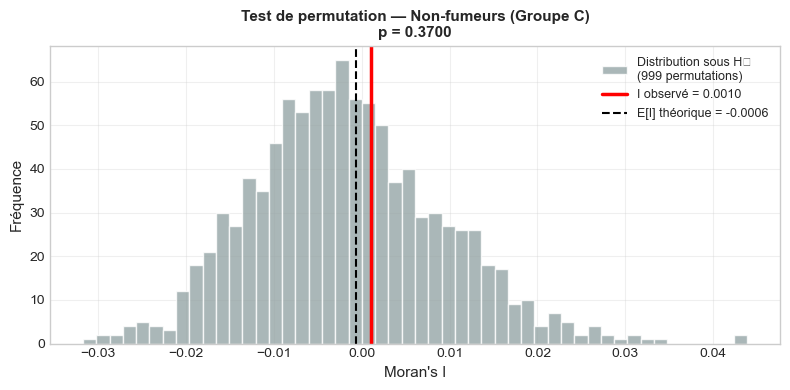

In [9]:
res_moran_C = moran.moran_global_univarie(
    df, W,
    variable = 'groupe_C',
    label    = 'Non-fumeurs (Groupe C)',
    couleur  = '#52B788',
    n_perm   = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran I — Non-fumeurs

*À compléter après exécution.*

### 3c — Score exposition Seveso SH

  ⚠️  71 patients isolés exclus du calcul

  Score exposition Seveso SH
  Moran's I = 0.6563 | E[I] = -0.0006
  z-score   = 60.8459
  p-value   = 0.0000 ✅ sig.
  p-valeur (permutation) = 0.0010 ✅ sig.


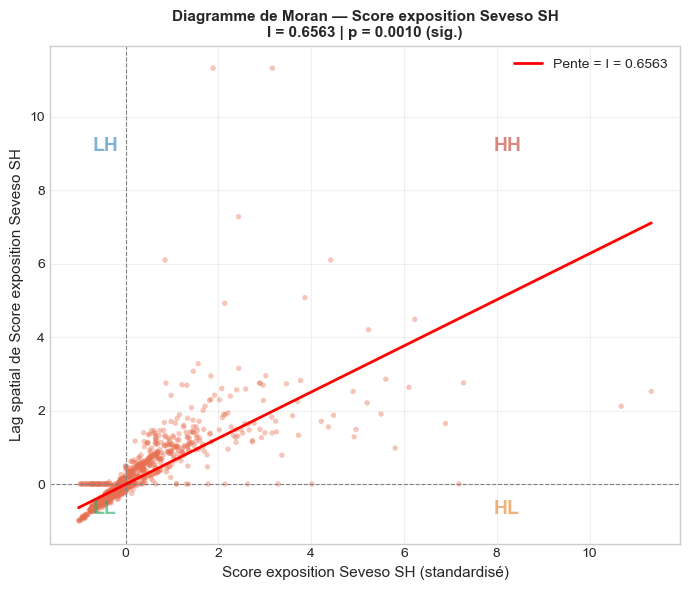

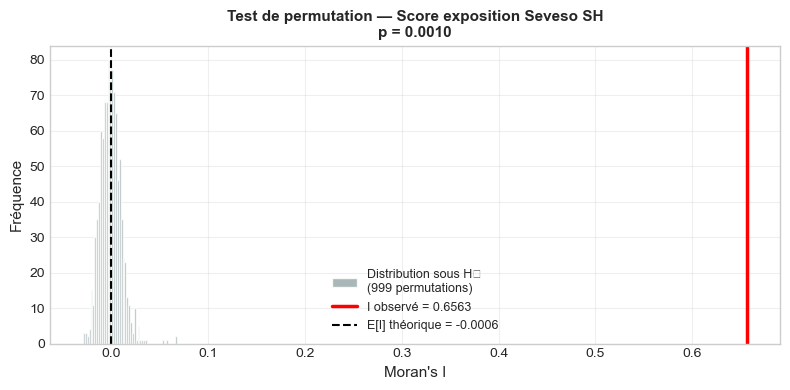

In [10]:
res_moran_SH = moran.moran_global_univarie(
    df, W,
    variable = 'score_expo_SH',
    label    = 'Score exposition Seveso SH',
    couleur  = '#E76F51',
    n_perm   = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran I — Score exposition SH

*À compléter après exécution.*

### 3d — Nombre de Seveso SH dans 3km

  ⚠️  71 patients isolés exclus du calcul

  Nb Seveso SH dans 3km
  Moran's I = 0.4877 | E[I] = -0.0006
  z-score   = 45.2288
  p-value   = 0.0000 ✅ sig.
  p-valeur (permutation) = 0.0010 ✅ sig.


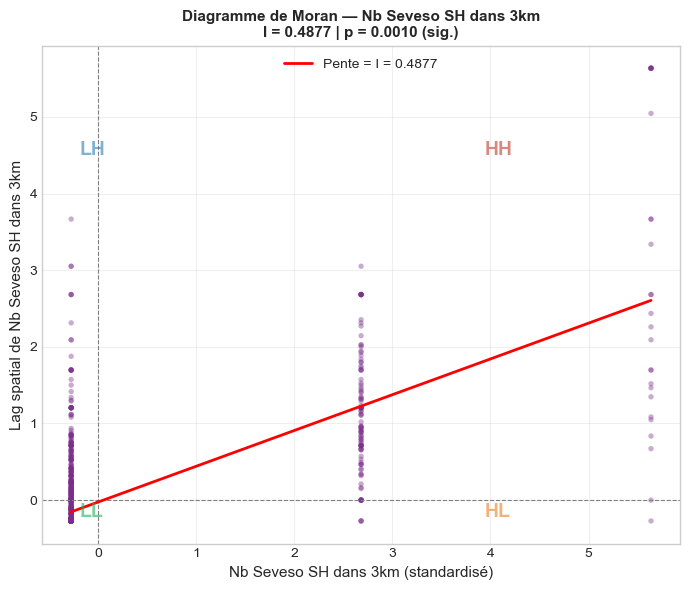

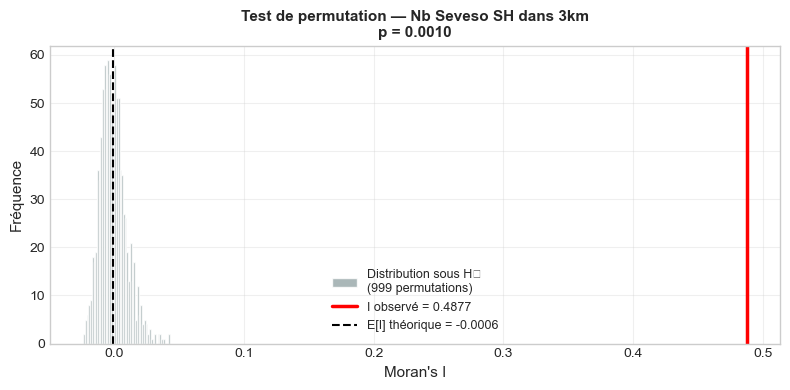

In [11]:
res_moran_nb = moran.moran_global_univarie(
    df, W,
    variable = 'nb_SH_3km',
    label    = 'Nb Seveso SH dans 3km',
    couleur  = '#7B2D8B',
    n_perm   = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran I — Nb SH 3km

*À compléter après exécution.*

---
## PARTIE 4 — LISA (Indicateurs locaux d'association spatiale)

> Identifie **où** dans l'IDF se trouvent les clusters spatiaux.
>
> | Quadrant | Signification |
> |---|---|
> | **HH** (rouge) | Forte valeur entourée de fortes valeurs → cluster positif |
> | **LL** (vert) | Faible valeur entourée de faibles valeurs → cluster négatif |
> | **HL** (orange) | Forte valeur entourée de faibles valeurs → outlier |
> | **LH** (bleu) | Faible valeur entourée de fortes valeurs → outlier |


### 4a — LISA mutations NF (Groupe A)


  LISA — Mutations NF (Groupe A)
    HH (cluster positif)  : 1 patients
    LL (cluster négatif)  : 220 patients
    HL (outlier spatial)  : 23 patients
    LH (outlier spatial)  : 50 patients
    Non significatif      : 1388 patients


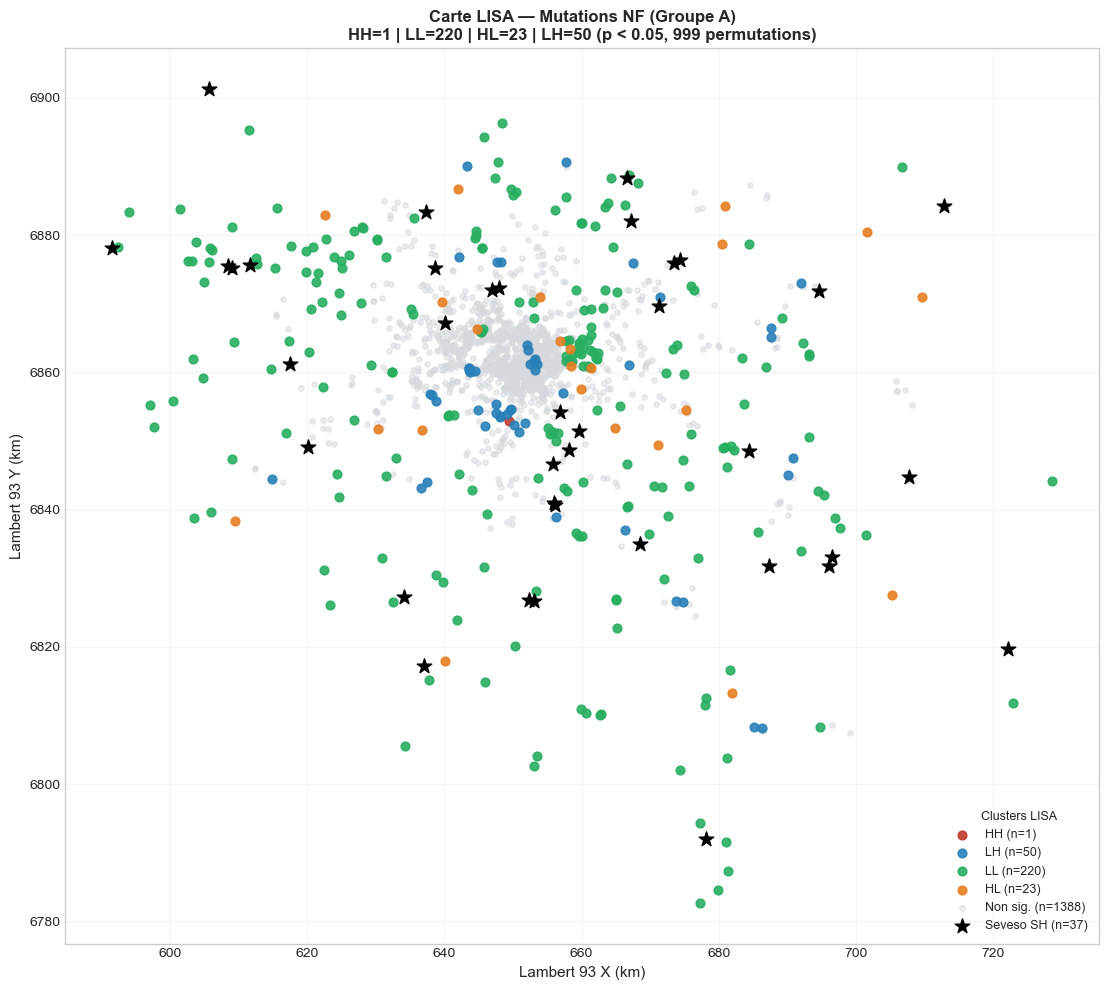


Clusters HH (mutations NF regroupées) : 1
→ Ces 1 patients forment des zones de concentration
  de mutations NF. Coïncident-ils avec des Seveso SH ? → voir carte


In [12]:
df, lisa_A, clusters_A = moran.lisa_local(
    df, W,
    variable = 'groupe_A',
    label    = 'Mutations NF (Groupe A)',
    icpe_sh  = icpe_sh,
    n_perm   = CONFIG['n_permutations'],
    alpha    = CONFIG['alpha']
)

print(f"\nClusters HH (mutations NF regroupées) : {clusters_A['HH']}")
print(f"→ Ces {clusters_A['HH']} patients forment des zones de concentration")
print(f"  de mutations NF. Coïncident-ils avec des Seveso SH ? → voir carte")


#### 📊 Résultats — LISA — Mutations NF

*À compléter après exécution.*

### 4b — LISA non-fumeurs (Groupe C)


  LISA — Non-fumeurs (Groupe C)
    HH (cluster positif)  : 11 patients
    LL (cluster négatif)  : 454 patients
    HL (outlier spatial)  : 83 patients
    LH (outlier spatial)  : 123 patients
    Non significatif      : 1011 patients


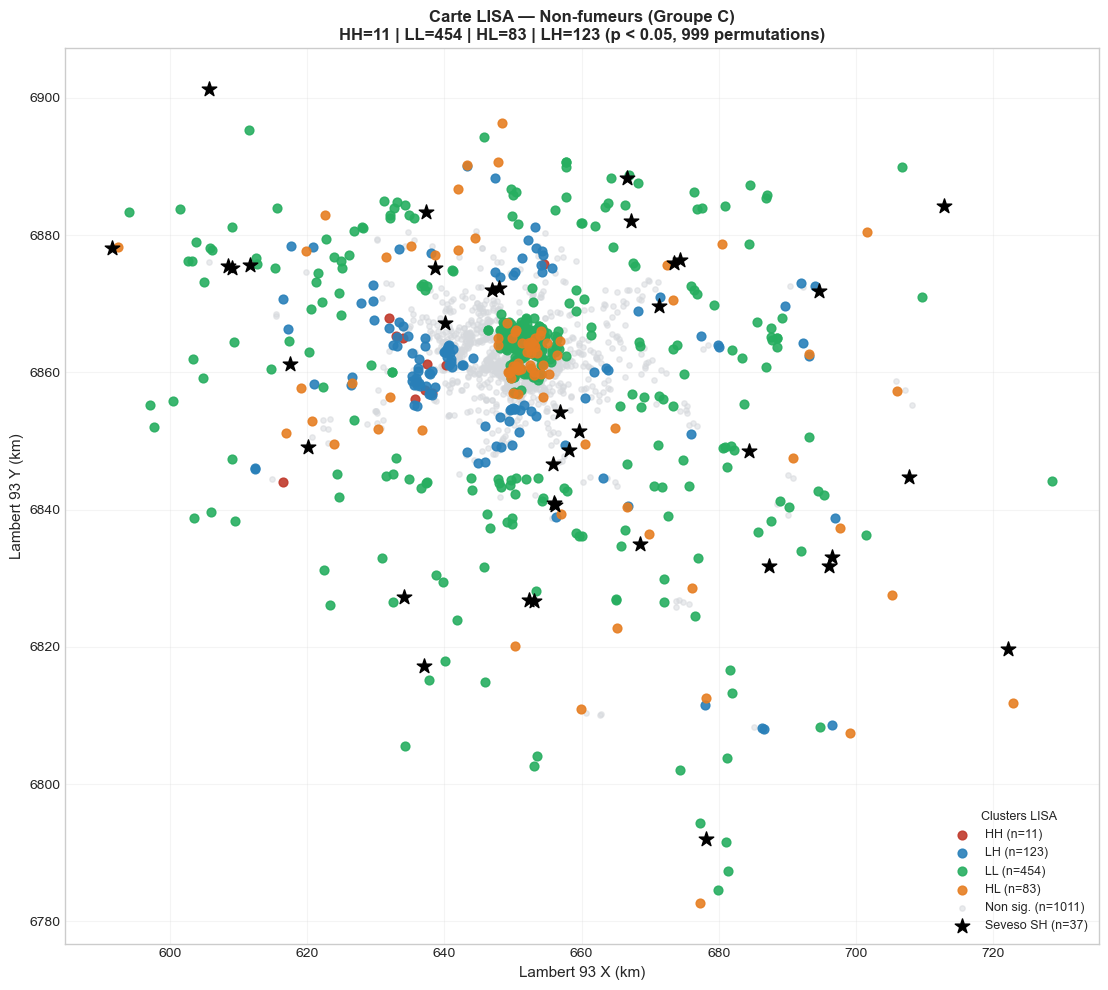

In [13]:
df, lisa_C, clusters_C = moran.lisa_local(
    df, W,
    variable = 'groupe_C',
    label    = 'Non-fumeurs (Groupe C)',
    icpe_sh  = icpe_sh,
    n_perm   = CONFIG['n_permutations'],
    alpha    = CONFIG['alpha']
)


#### 📊 Résultats — LISA — Non-fumeurs

*À compléter après exécution.*

---
## PARTIE 5 — Moran's I bivarié ★

> **C'est la réponse directe à la question principale :**
> les zones avec beaucoup de patients mutés NF sont-elles
> spatialement associées aux zones proches des Seveso SH ?
>
> **I_biv > 0 et p < 0.05** → co-clustering positif :
> mutations NF et Seveso SH se retrouvent dans les mêmes zones.
>
> **I_biv ≈ 0** → aucune association spatiale entre les deux.


### 5a — Mutations NF × Score exposition SH


  Moran bivarié : Mutations NF × Score expo Seveso SH
  I bivarié = 0.0164
  z-score   = 2.2127
  p-value (permutation) = 0.0230 ✅ sig.


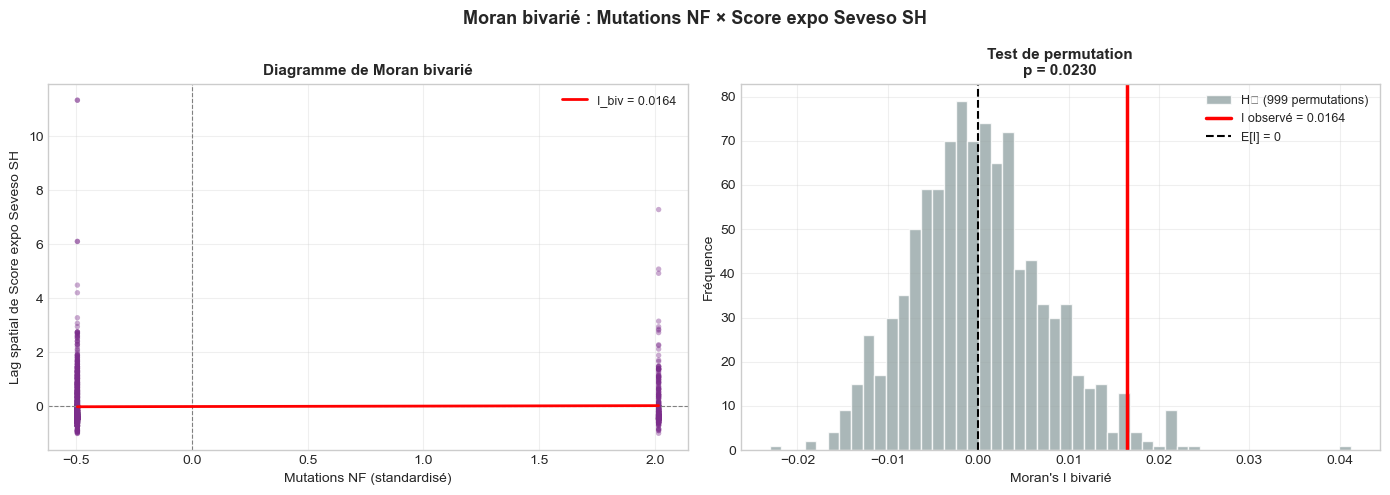


Interprétation :
  ✅ Association spatiale POSITIVE significative
     Les zones avec beaucoup de mutés NF sont proches des Seveso SH


In [14]:
res_bv_A_score = moran.moran_bivarie(
    df, W,
    var_x   = 'groupe_A',
    var_y   = 'score_expo_SH',
    label_x = 'Mutations NF',
    label_y = 'Score expo Seveso SH',
    n_perm  = CONFIG['n_permutations']
)

print(f"\nInterprétation :")
if res_bv_A_score['p_sim'] < CONFIG['alpha']:
    if res_bv_A_score['I'] > 0:
        print(f"  ✅ Association spatiale POSITIVE significative")
        print(f"     Les zones avec beaucoup de mutés NF sont proches des Seveso SH")
    else:
        print(f"  ✅ Association spatiale NÉGATIVE significative")
        print(f"     Les zones avec beaucoup de mutés NF s'éloignent des Seveso SH")
else:
    print(f"  — Pas d'association spatiale significative")
    print(f"     Les mutations NF sont distribuées indépendamment des Seveso SH")


#### 📊 Résultats — Moran bivarié — Mutations NF × Score expo SH

*À compléter après exécution.*

### 5b — Mutations NF × Nombre de Seveso SH dans 3km


  Moran bivarié : Mutations NF × Nb SH 3km
  I bivarié = 0.0227
  z-score   = 3.1309
  p-value (permutation) = 0.0040 ✅ sig.


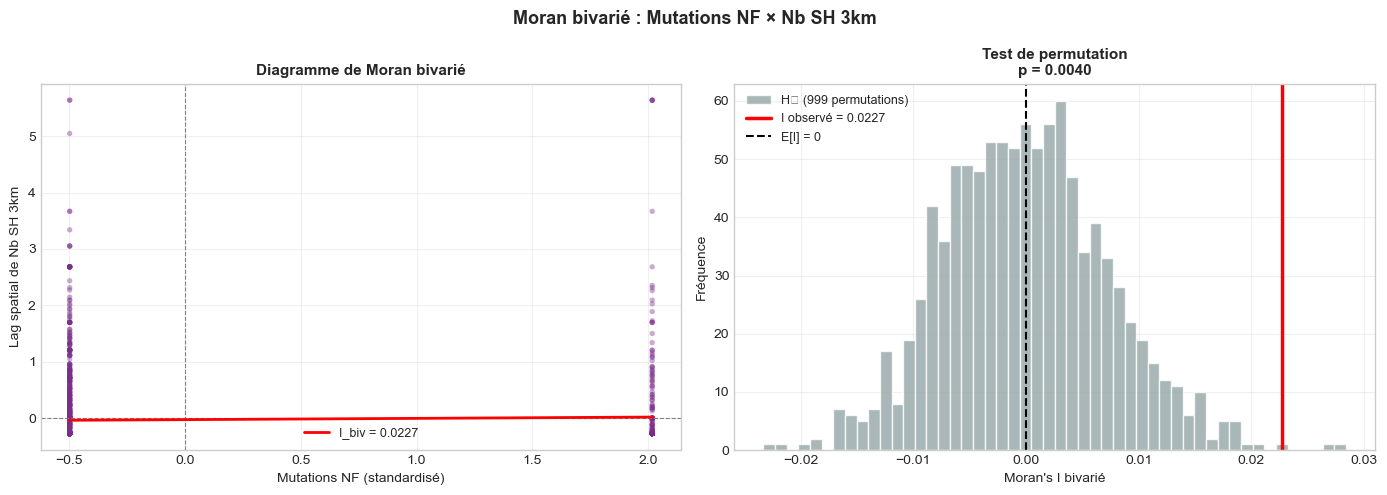

In [15]:
res_bv_A_nb = moran.moran_bivarie(
    df, W,
    var_x   = 'groupe_A',
    var_y   = 'nb_SH_3km',
    label_x = 'Mutations NF',
    label_y = 'Nb SH 3km',
    n_perm  = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran bivarié — Mutations NF × Nb SH

*À compléter après exécution.*

### 5c — Groupe A+C (mutations NF + non-fumeurs) × Score exposition SH


  Moran bivarié : Mutations NF + Non-fumeurs (A+C) × Score expo Seveso SH
  I bivarié = 0.0054
  z-score   = 0.7560
  p-value (permutation) = 0.2080 — non sig.


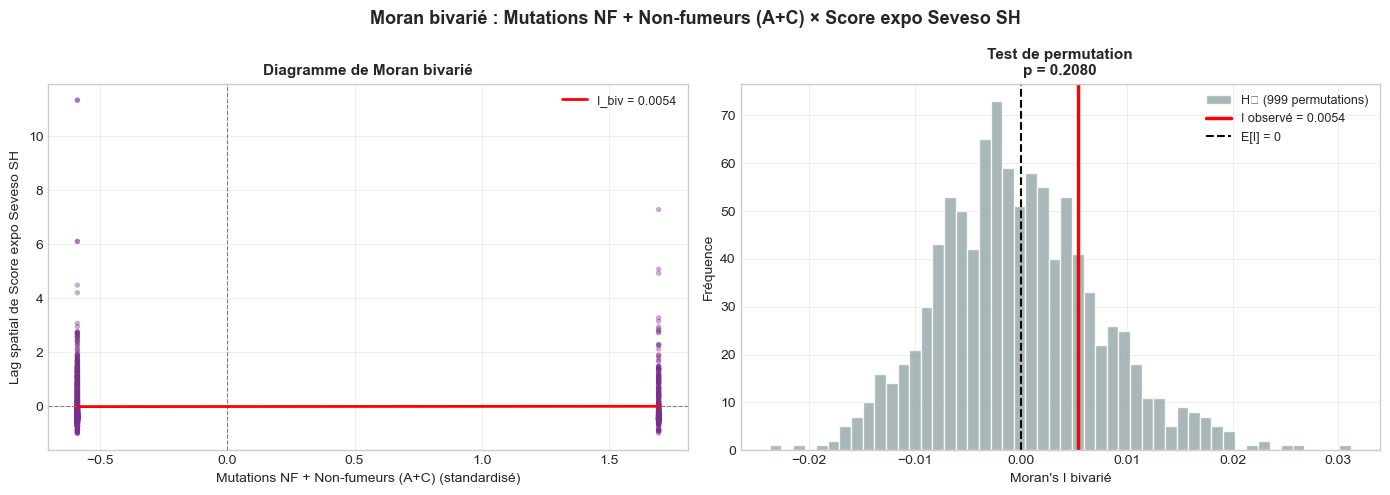

In [16]:
res_bv_AC_score = moran.moran_bivarie(
    df, W,
    var_x   = 'groupe_AC',
    var_y   = 'score_expo_SH',
    label_x = 'Mutations NF + Non-fumeurs (A+C)',
    label_y = 'Score expo Seveso SH',
    n_perm  = CONFIG['n_permutations']
)


#### 📊 Résultats — Moran bivarié — Groupe A+C × Score expo SH

*À compléter après exécution.*

---
## PARTIE 6 — LISA bivarié ★

> Identifie **localement** les zones de co-clustering entre mutations NF et Seveso SH.
>
> **Quadrant HH** (rouge) → zones où patients mutés NF ET forte exposition SH coexistent.
> C'est ici qu'un signal géographique potentiellement important se manifeste.


### 6a — LISA bivarié : Mutations NF × Score exposition SH


  LISA bivarié : Mutations NF × Score expo SH
    HH (co-cluster positif)  : 64 patients
      → zones où mutés NF ET forte exposition SH coexistent
    LL (co-cluster négatif)  : 816 patients
    HL/LH (outliers)         : 439 patients
    Non significatif         : 363 patients


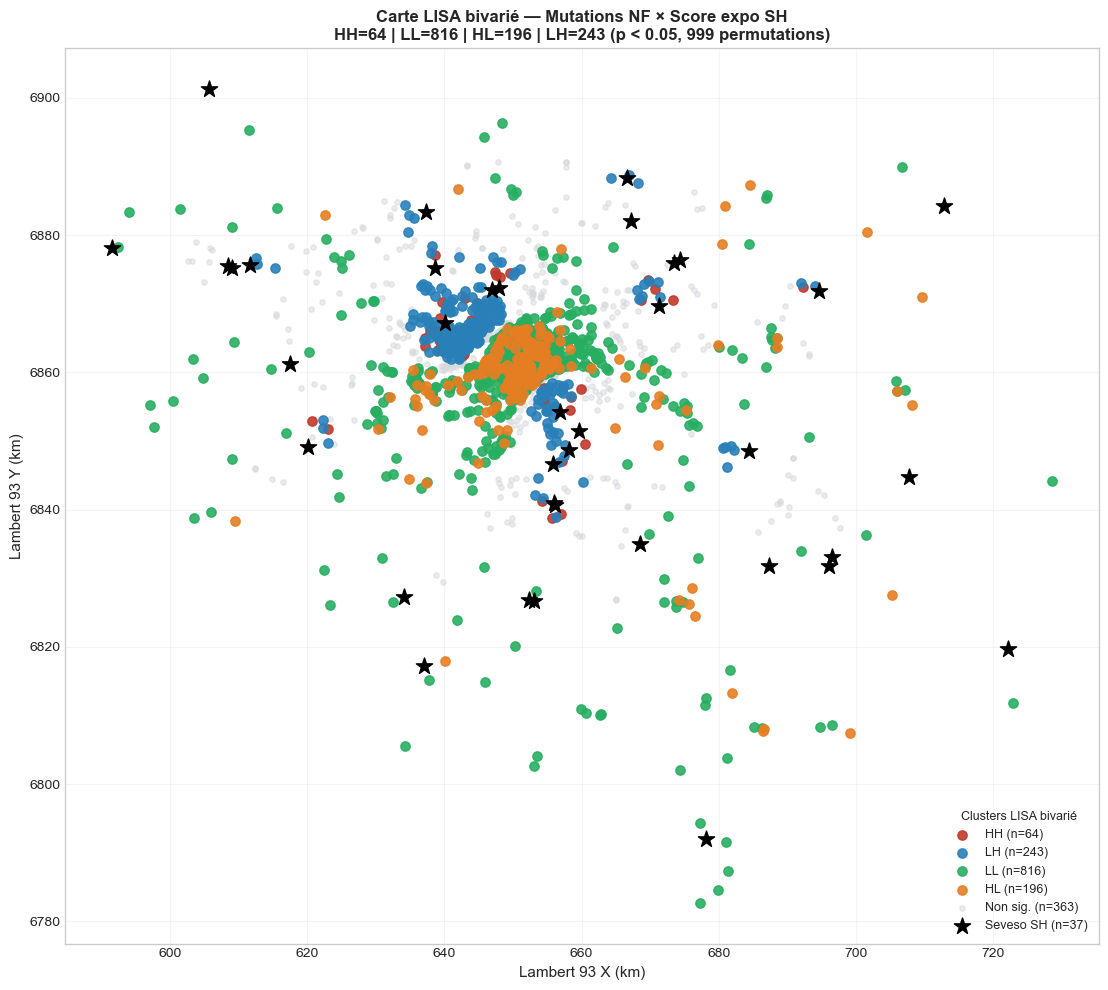


Co-clusters HH (mutations NF ET forte expo SH) : 64

Caractéristiques des 64 patients HH :
  dist_SH_m médiane  : 3131 m
  nb_SH_3km médiane  : 0.0


In [17]:
df, lisa_bv_A, clusters_bv_A = moran.lisa_bivarie(
    df, W,
    var_x   = 'groupe_A',
    var_y   = 'score_expo_SH',
    label_x = 'Mutations NF',
    label_y = 'Score expo SH',
    icpe_sh = icpe_sh,
    n_perm  = CONFIG['n_permutations'],
    alpha   = CONFIG['alpha']
)

print(f"\nCo-clusters HH (mutations NF ET forte expo SH) : {clusters_bv_A['HH']}")
if clusters_bv_A['HH'] > 0:
    # Localisation des clusters HH
    hh_patients = df[df['lisa_bv_type'] == 'HH'][['pseudo_provisoire',
                                                     'x_l93','y_l93',
                                                     'dist_SH_m','nb_SH_3km']]
    print(f"\nCaractéristiques des {clusters_bv_A['HH']} patients HH :")
    print(f"  dist_SH_m médiane  : {hh_patients['dist_SH_m'].median():.0f} m")
    print(f"  nb_SH_3km médiane  : {hh_patients['nb_SH_3km'].median():.1f}")
else:
    print("  → Aucun co-cluster HH significatif")


#### 📊 Résultats — LISA bivarié — Mutations NF × Score expo SH

*À compléter après exécution.*

### 6b — LISA bivarié : Groupe A+C × Score exposition SH


  LISA bivarié : Groupe A+C × Score expo SH
    HH (co-cluster positif)  : 78 patients
      → zones où mutés NF ET forte exposition SH coexistent
    LL (co-cluster négatif)  : 760 patients
    HL/LH (outliers)         : 481 patients
    Non significatif         : 363 patients


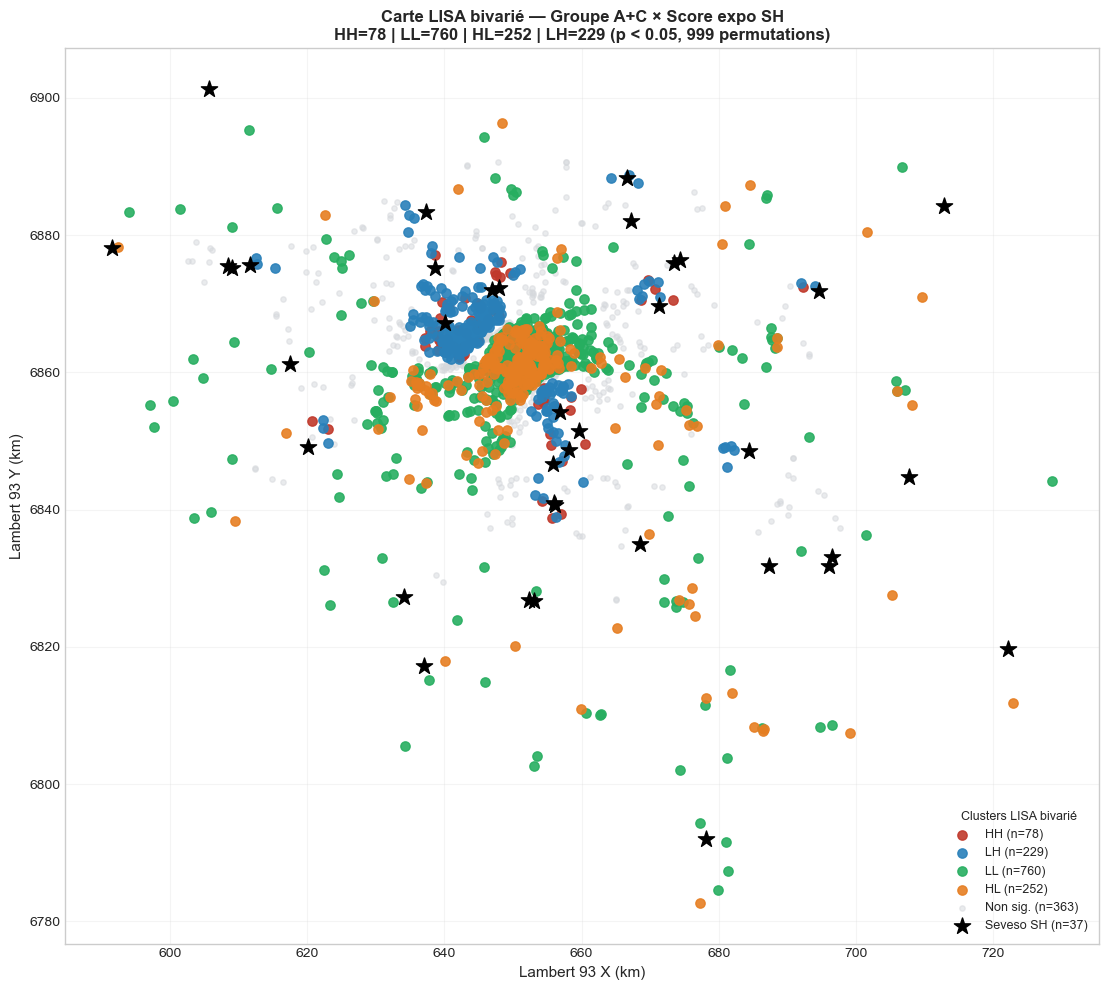

In [18]:
df, lisa_bv_AC, clusters_bv_AC = moran.lisa_bivarie(
    df, W,
    var_x   = 'groupe_AC',
    var_y   = 'score_expo_SH',
    label_x = 'Groupe A+C',
    label_y = 'Score expo SH',
    icpe_sh = icpe_sh,
    n_perm  = CONFIG['n_permutations'],
    alpha   = CONFIG['alpha']
)


#### 📊 Résultats — LISA bivarié — Groupe A+C × Score expo SH

*À compléter après exécution.*

---
## PARTIE 7 — Synthèse des résultats

> Tableau récapitulatif de tous les indices de Moran calculés.
> Les résultats sont sauvegardés en CSV dans `output_dir`.



═════════════════════════════════════════════════════════════════
SYNTHÈSE DES ANALYSES DE MORAN
═════════════════════════════════════════════════════════════════
                                                                  Analyse     Type       I  z-score p_fmt Sig               Interp.
                                 Moran I global — Mutations NF (Groupe A) Univarié -0.0081  -0.6974 0.224   —    Clustering négatif
                                  Moran I global — Non-fumeurs (Groupe C) Univarié  0.0010   0.1520 0.370   —    Clustering positif
                              Moran I global — Score exposition Seveso SH Univarié  0.6563  60.8459 0.001   ✅    Clustering positif
                                   Moran I global — Nb Seveso SH dans 3km Univarié  0.4877  45.2288 0.001   ✅    Clustering positif
                    Moran I bivarié — Mutations NF × Score expo Seveso SH  Bivarié  0.0164   2.2127 0.023   ✅ Co-clustering positif
                               Moran I bivar

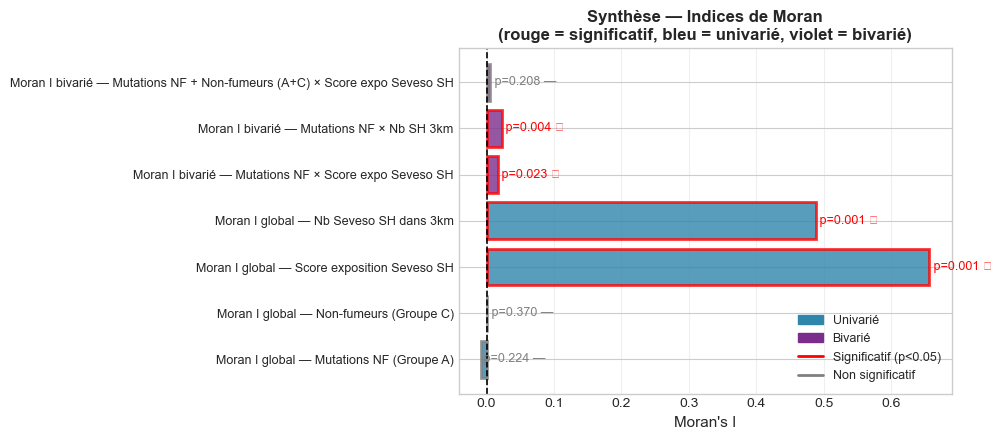

In [19]:
resultats_global  = [res_moran_A, res_moran_C, res_moran_SH, res_moran_nb]
resultats_bivarie = [res_bv_A_score, res_bv_A_nb, res_bv_AC_score]

df_synthese = moran.synthese_resultats(resultats_global, resultats_bivarie)


#### 📊 Résultats — Synthèse Moran

*À compléter après exécution.*

### 7b — Interprétation finale

In [20]:
print("═"*65)
print("INTERPRÉTATION FINALE")
print("═"*65)

# Moran global groupe A
I_A = res_moran_A['I']; p_A = res_moran_A['p_sim']
print(f"\n1. Clustering spatial des mutations NF :")
print(f"   Moran I = {I_A:.4f} | p = {'<0.001' if p_A<0.001 else f'{p_A:.3f}'}")
if p_A < CONFIG['alpha']:
    if I_A > 0:
        print(f"   ✅ Les mutations NF sont spatialement CLUSTÉRISÉES en IDF")
        print(f"      (elles ne sont pas distribuées aléatoirement)")
    else:
        print(f"   ✅ Les mutations NF sont spatialement DISPERSÉES")
else:
    print(f"   — Les mutations NF sont distribuées ALÉATOIREMENT dans l'espace")

# Moran bivarié A × SH
I_bv = res_bv_A_score['I']; p_bv = res_bv_A_score['p_sim']
print(f"\n2. Association spatiale mutations NF × Seveso SH :")
print(f"   Moran I bivarié = {I_bv:.4f} | p = {'<0.001' if p_bv<0.001 else f'{p_bv:.3f}'}")
if p_bv < CONFIG['alpha']:
    if I_bv > 0:
        print(f"   ✅ CO-CLUSTERING POSITIF significatif")
        print(f"      Les zones à forte densité de mutés NF sont proches des Seveso SH")
        print(f"      → Signal spatial à investiguer")
    else:
        print(f"   ✅ CO-CLUSTERING NÉGATIF significatif")
        print(f"      Les mutés NF habitent LOIN des Seveso SH")
else:
    print(f"   — AUCUNE association spatiale significative")
    print(f"      Les mutations NF et les Seveso SH sont indépendants spatialement")

# Co-clusters HH
print(f"\n3. Co-clusters HH (mutations NF ET forte expo SH) :")
print(f"   Nombre de patients : {clusters_bv_A['HH']}")
if clusters_bv_A['HH'] > 0:
    print(f"   ⚠️  Ces zones méritent une investigation géospatiale approfondie")
else:
    print(f"   — Aucune zone de co-clustering détectée")

print(f"\n4. Mise en garde :")
print(f"   Un Moran bivarié significatif indique une co-localisation spatiale,")
print(f"   PAS une relation causale entre Seveso SH et mutations NF.")
print(f"   Des facteurs de confusion géographiques doivent être exclus.")


═════════════════════════════════════════════════════════════════
INTERPRÉTATION FINALE
═════════════════════════════════════════════════════════════════

1. Clustering spatial des mutations NF :
   Moran I = -0.0081 | p = 0.224
   — Les mutations NF sont distribuées ALÉATOIREMENT dans l'espace

2. Association spatiale mutations NF × Seveso SH :
   Moran I bivarié = 0.0164 | p = 0.023
   ✅ CO-CLUSTERING POSITIF significatif
      Les zones à forte densité de mutés NF sont proches des Seveso SH
      → Signal spatial à investiguer

3. Co-clusters HH (mutations NF ET forte expo SH) :
   Nombre de patients : 64
   ⚠️  Ces zones méritent une investigation géospatiale approfondie

4. Mise en garde :
   Un Moran bivarié significatif indique une co-localisation spatiale,
   PAS une relation causale entre Seveso SH et mutations NF.
   Des facteurs de confusion géographiques doivent être exclus.
